# Telecom Customer Churn (Feature Engineering & Data Preprocessing)

## Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize

In [2]:
df = pd.read_csv("telecom_customer_churn_feature_engineering.csv")

## Initial Data Exploration (EDA)

In [3]:
df[["monthly_income", "monthly_bill"]].head()

,monthly_income,monthly_bill
0,57643.0,10049.0
1,18207.0,2752.0
2,13075.0,3155.0
3,38890.0,5859.0
4,17475.0,5106.0


In [4]:
df[["monthly_income", "monthly_bill"]].describe()

,monthly_income,monthly_bill
count,1200.000000,1200.000000
mean,31155.975833,5939.150833
std,19351.937726,4046.473963
min,4984.000000,710.000000
25%,17795.000000,3291.750000
50%,26628.000000,4871.000000
75%,39886.250000,7485.500000
max,209790.000000,36361.000000


## Train-Test Split
  1. Split data first
  2. Fit scaler on training data only
  3. Transform train and test separately

### Shuffle DataSet
- `frac=1` → take 100% of rows
- rows are randomly shuffled
- `random_state=42` ensures reproducible results

Without shuffling:
- data may be ordered
- train/test split could become biased

In [5]:
df_shuffled = df.sample(
    frac=1,
    random_state=42
)

### Calculate Training Size
| Dataset       | Percentage |
| ------------- | ---------- |
| Training Data | 80%        |
| Testing Data  | 20%        |

In [6]:
len(df_shuffled)

1200

In [7]:
train_size = int(0.8 * len(df_shuffled))
train_size

960

### Split Dataset

In [8]:
train_df = df_shuffled.iloc[:train_size]
test_df = df_shuffled.iloc[train_size:]

In [9]:
len(train_df), len(test_df)
print("For",len(df_shuffled),":\n80% training data is", len(train_df), "and 20% testing data is", len(test_df))

For 1200 :
80% training data is 960 and 20% testing data is 240


### Verify No Overlap
- No duplicate rows
- Train and test are separate

In [10]:
set(train_df.index).intersection(set(test_df.index))

set()

## Scaling

### Z-Score Standardization
Z-score scaling transforms data so that:
* Mean becomes approximately `0`
* Standard deviation becomes approximately `1`

#### Problem (Data Leakage)
- Happens when Information from test data Accidentally influences training
- This causes Unrealistically high model accuracy and Poor real-world performance

In [11]:
# Calculate Mean
income_mean = df["monthly_income"].mean()
income_mean

31155.975833333334

In [12]:
# Calculate Standard Deviation
income_std = df["monthly_income"].std()
income_std

19351.937725889493

In [13]:
# Apply Z-Score Formula
df["income_zscore"] = (
    (df["monthly_income"] - income_mean) / income_std
)

df[["monthly_income", "income_zscore"]].head()

,monthly_income,income_zscore
0,57643.0,1.368701
1,18207.0,-0.669131
2,13075.0,-0.934324
3,38890.0,0.399651
4,17475.0,-0.706956


In [14]:
# Verify Scaling
df["income_zscore"].mean(), df["income_zscore"].std()

(-1.628327102783563e-17, 0.9999999999999997)

#### Solution (Train-Test Split):
  1. Split data first
  2. Fit scaler on training data only
  3. Transform train and test separately`

In [15]:
# Calculate Mean
income_mean = train_df["monthly_income"].mean()
income_mean

31264.78125

In [16]:
# Calculate Standard Deviation
income_std = train_df["monthly_income"].std()
income_std

19693.08528827001

In [17]:
# Apply to training data
train_df = train_df.copy()
train_df["income_zscore"] = (
    (train_df["monthly_income"] - income_mean) / income_std
)

In [18]:
train_df["income_zscore"].mean(), train_df["income_zscore"].std()

(7.401486830834377e-18, 1.0000000000000002)

In [19]:
# Apply SAME transformation to test data
test_df = test_df.copy()
test_df["income_zscore"] = (
    (test_df["monthly_income"] - income_mean) / income_std
)

In [20]:
# Verify Scaling
test_df["income_zscore"].mean(), test_df["income_zscore"].std()

(-0.02762528447776425, 0.9117370781588747)

In [21]:
print("Training Data:")
train_df[["monthly_income", "income_zscore"]].head()

Training Data:


,monthly_income,income_zscore
1178,35587.0,0.219479
865,19160.0,-0.614672
101,13378.0,-0.908277
439,20382.0,-0.552619
58,19100.0,-0.617718


In [22]:
print("Testing Data:")
test_df[["monthly_income", "income_zscore"]].head()

Testing Data:


,monthly_income,income_zscore
985,16005.0,-0.774880
851,21150.0,-0.513621
103,36295.0,0.255431
421,11727.0,-0.992114
419,9008.0,-1.130183


#### Visualization

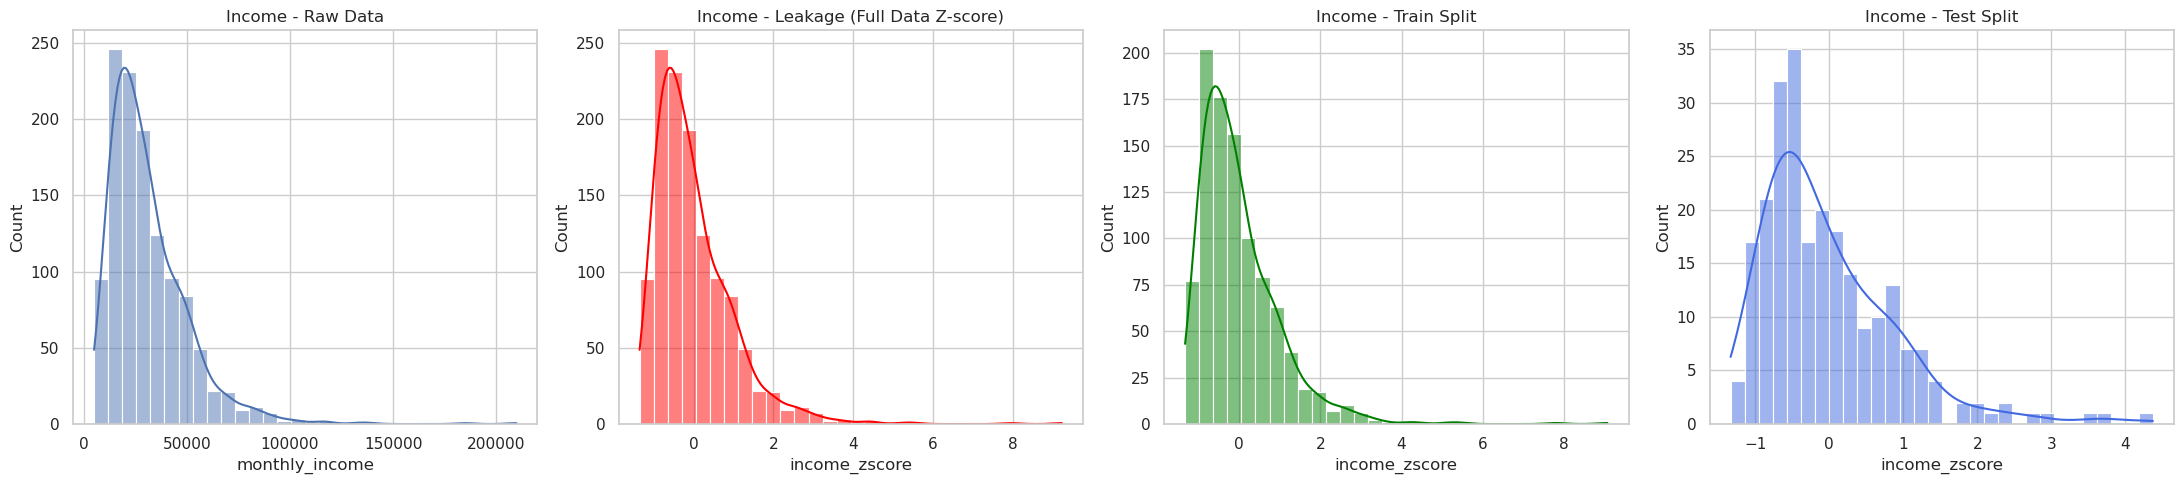

In [69]:
sns.set(style="whitegrid")

plt.figure(figsize=(22, 5))

# Raw Income
plt.subplot(1, 4, 1)
sns.histplot(df["monthly_income"], kde=True, bins=30)
plt.title("Income - Raw Data")

# Leakage (Z-score full dataset)
plt.subplot(1, 4, 2)
sns.histplot(df["income_zscore"], kde=True, bins=30,color="red")
plt.title("Income - Leakage (Full Data Z-score)")

# Train split
plt.subplot(1, 4, 3)
sns.histplot(train_df["income_zscore"], kde=True, bins=30,color="green")
plt.title("Income - Train Split")

# Test split
plt.subplot(1, 4, 4)
sns.histplot(test_df["income_zscore"], kde=True, bins=30,color="royalblue")
plt.title("Income - Test Split")

plt.tight_layout()
plt.savefig("Income Visualizations (Z-Score)")
plt.show()

### Min-Max Normalization 
Min-Max normalization converts values into the range:

```python
0 → 1
```

#### Problem (Data Leakage)
- Happens when Information from test data Accidentally influences training
- This causes Unrealistically high model accuracy and Poor real-world performance

In [24]:
# Find Minimum Value
bill_min = df["monthly_bill"].min()
bill_min

710.0

In [25]:
# Find Maximum Value
bill_max = df["monthly_bill"].max()
bill_max

36361.0

In [26]:
# Apply Min-Max Formula
df["bill_minmax"] = (
    (df["monthly_bill"] - bill_min)
    / (bill_max - bill_min)
)
df[["monthly_bill", "bill_minmax"]].head()

,monthly_bill,bill_minmax
0,10049.0,0.261956
1,2752.0,0.057277
2,3155.0,0.068582
3,5859.0,0.144428
4,5106.0,0.123306


In [27]:
# Verify Min-Max Scaling
df["bill_minmax"].min(), df["bill_minmax"].max()

(0.0, 1.0)

In [28]:
# Check Extreme and Middle Values
df.loc[
    [
        df["monthly_bill"].idxmin(),
        df["monthly_bill"].idxmax(),
        df["monthly_bill"].sort_values().index[len(df)//2]
    ],
    ["monthly_bill", "bill_minmax"]
]

,monthly_bill,bill_minmax
893,710.0,0.000000
968,36361.0,1.000000
47,4873.0,0.116771


#### Solution (Train-Test Split):
  1. Split data first
  2. Fit scaler on training data only
  3. Transform train and test separately`

In [29]:
# Find Minimum Value
bill_min = train_df["monthly_bill"].min()
bill_min

710.0

In [30]:
# Find Maximum Value
bill_max = train_df["monthly_bill"].max()
bill_max

36361.0

In [31]:
# Apply Min-Max Formula
train_df["bill_minmax"] = (
    (train_df["monthly_bill"] - bill_min) / (bill_max - bill_min)
)

In [32]:
# Apply Min-Max Formula
test_df["bill_minmax"] = (
    (test_df["monthly_bill"] - bill_min) / (bill_max - bill_min)
)

In [33]:
# Verify Scaling
test_df["bill_minmax"].min(), test_df["bill_minmax"].max()

(0.00490869821323385, 0.7051976101652128)

In [34]:
print("Training Data:")
train_df[["monthly_bill", "bill_minmax"]].head()

Training Data:


,monthly_bill,bill_minmax
1178,3191.0,0.069591
865,7771.0,0.198059
101,13330.0,0.353987
439,7579.0,0.192673
58,23867.0,0.649547


In [35]:
print("\nTesting Data:")
test_df[["monthly_bill", "bill_minmax"]].head()


Testing Data:


,monthly_bill,bill_minmax
985,1676.0,0.027096
851,2310.0,0.044880
103,1990.0,0.035904
421,5518.0,0.134863
419,15515.0,0.415276


In [36]:
# Check Extreme and Middle Values
train_df.loc[
    [
        train_df["monthly_bill"].idxmin(),
        train_df["monthly_bill"].idxmax(),
        train_df["monthly_bill"].sort_values().index[len(train_df)//2]
    ],
    ["monthly_bill", "bill_minmax"]
]

,monthly_bill,bill_minmax
893,710.0,0.000000
968,36361.0,1.000000
309,4902.0,0.117584


In [37]:
# Check Extreme and Middle Values
test_df.loc[
    [
        test_df["monthly_bill"].idxmin(),
        test_df["monthly_bill"].idxmax(),
        test_df["monthly_bill"].sort_values().index[len(test_df)//2]
    ],
    ["monthly_bill", "bill_minmax"]
]

,monthly_bill,bill_minmax
563,885.0,0.004909
484,25851.0,0.705198
897,4672.0,0.111133


#### Visualization

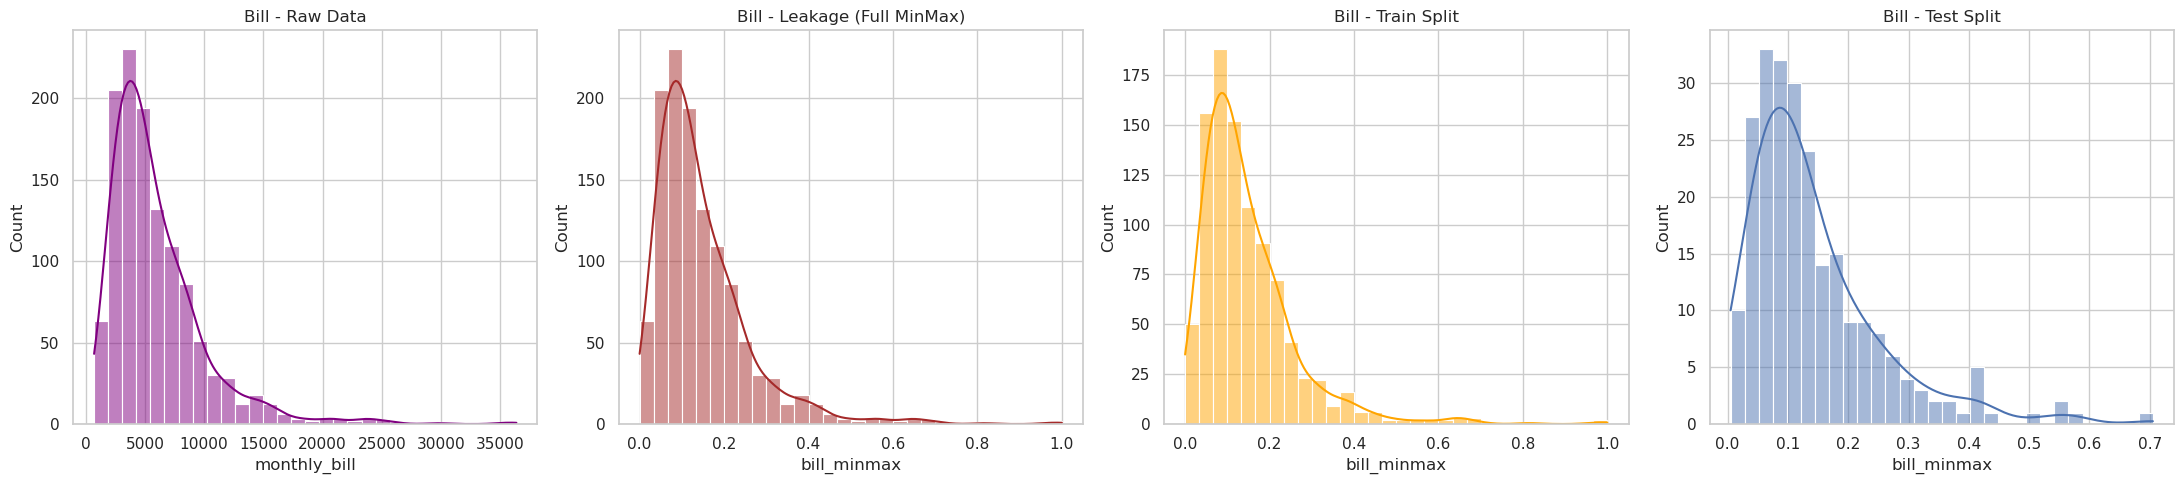

In [70]:
sns.set(style="whitegrid")

plt.figure(figsize=(22, 5))

# Raw Bill
plt.subplot(1, 4, 1)
sns.histplot(df["monthly_bill"], kde=True, bins=30,color="purple")
plt.title("Bill - Raw Data")

# Leakage (Min-Max full dataset)
plt.subplot(1, 4, 2)
sns.histplot(df["bill_minmax"], kde=True, bins=30,color="brown")
plt.title("Bill - Leakage (Full MinMax)")

# Train split
plt.subplot(1, 4, 3)
sns.histplot(train_df["bill_minmax"], kde=True, bins=30,color="orange")
plt.title("Bill - Train Split")

# Test split
plt.subplot(1, 4, 4)
sns.histplot(test_df["bill_minmax"], kde=True, bins=30)
plt.title("Bill - Test Split")

plt.tight_layout()
plt.savefig("Bill Visualizations (Min-Max)")
plt.show()

### Log Transformation
`log1p(x)` : `log(1+x)`
* Handles zero values safely
  - Regular `np.log()` would fail on zero income values (log(0) = undefined)
  - `np.log1p(0) = ln(1) = 0`, which handles zero incomes gracefully
* Reduces skewness
  - Income data is typically right-skewed (few high earners, many lower earners)
* Compresses large values
  - while preserving smaller ones

Log transformation does not cause data leakage because no statistics are learned from the dataset.

In [39]:
# Apply Log Transform
df["income_log"] = np.log1p(df["monthly_income"])
df[["monthly_income", "income_log"]].head()

,monthly_income,income_log
0,57643.0,10.962041
1,18207.0,9.809616
2,13075.0,9.478534
3,38890.0,10.568518
4,17475.0,9.768584


In [40]:
df[["monthly_income", "income_log"]].describe()

,monthly_income,income_log
count,1200.000000,1200.000000
mean,31155.975833,10.185955
std,19351.937726,0.566190
min,4984.000000,8.514189
25%,17795.000000,9.786729
50%,26628.000000,10.189755
75%,39886.250000,10.593811
max,209790.000000,12.253867


## Outlier Handling

### Clipping
Clipping limits extreme values to reduce:
* Outlier influence
* Variance explosion
* Model instability

`quantile(0.99)`: 
- This finds the value below which 99% of the data lies.
- Only the top 1% extreme values are above this limit.

`clip(upper=upper_limit)`: 
- values below the limit stay unchanged
- values above the limit are replaced with upper_limit

#### Problem (Data Leakage)
- Happens when Information from test data Accidentally influences training
- This causes Unrealistically high model accuracy and Poor real-world performance

In [41]:
# Find 99th Percentile
upper_limit = df["monthly_bill"].quantile(0.99)
upper_limit

21696.399999999987

In [42]:
# Clip Extreme Values
df["bill_clipped"] = (
    df["monthly_bill"].clip(upper=upper_limit)
)

#### Solution (Train-Test Split):
1. Split data first
2. Fit scaler on training data only
3. Transform train and test separately`

In [43]:
# Find upper limit from TRAIN data only
upper_limit = train_df["monthly_bill"].quantile(0.99)

In [44]:
# Apply clipping
train_df["bill_clipped"] = (
    train_df["monthly_bill"].clip(upper=upper_limit)
)

In [45]:
test_df["bill_clipped"] = (
    test_df["monthly_bill"].clip(upper=upper_limit)
)

#### Visualization

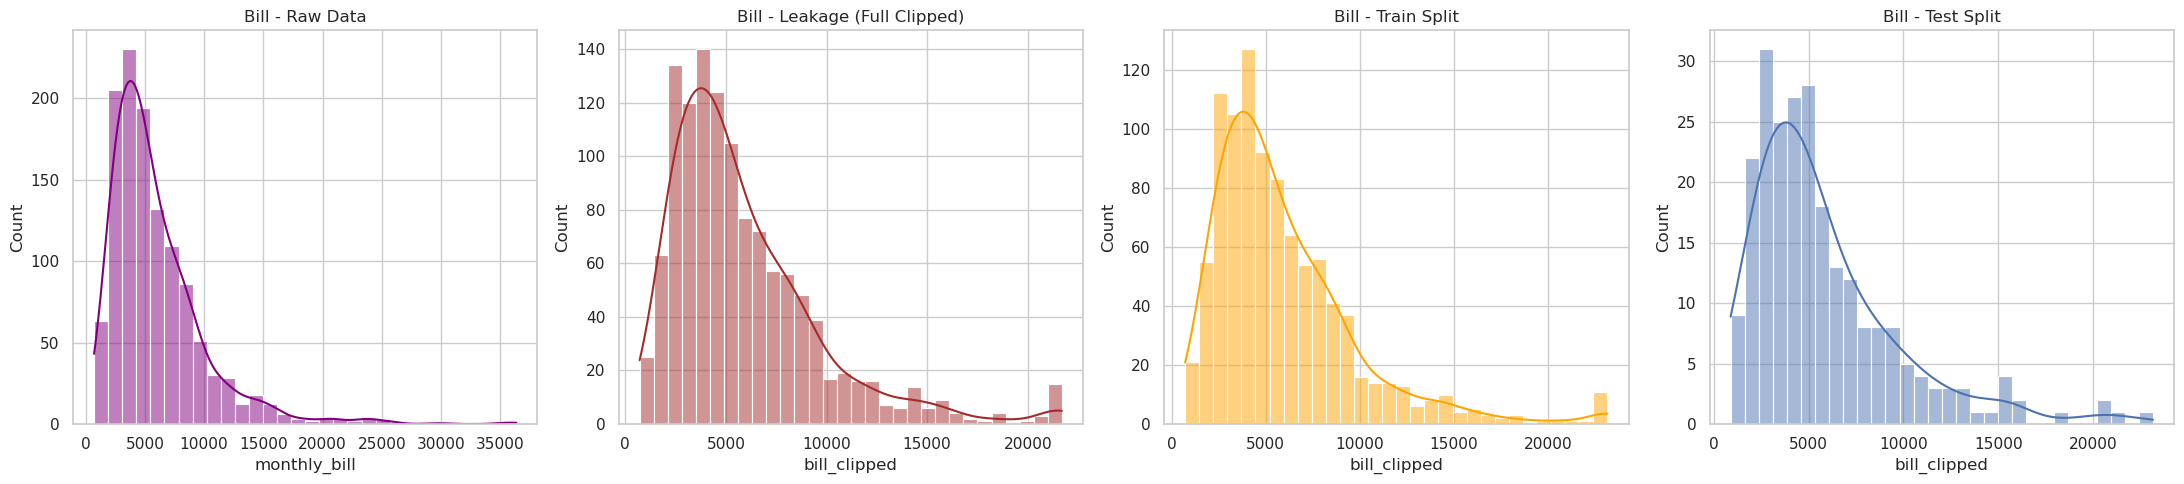

In [71]:
sns.set(style="whitegrid")

plt.figure(figsize=(22, 5))

# Raw Bill
plt.subplot(1, 4, 1)
sns.histplot(df["monthly_bill"], kde=True, bins=30,color="purple")
plt.title("Bill - Raw Data")

# Leakage (Min-Max full dataset)
plt.subplot(1, 4, 2)
sns.histplot(df["bill_clipped"], kde=True, bins=30,color="brown")
plt.title("Bill - Leakage (Full Clipped)")

# Train split
plt.subplot(1, 4, 3)
sns.histplot(train_df["bill_clipped"], kde=True, bins=30,color="orange")
plt.title("Bill - Train Split")

# Test split
plt.subplot(1, 4, 4)
sns.histplot(test_df["bill_clipped"], kde=True, bins=30)
plt.title("Bill - Test Split")

plt.tight_layout()
plt.savefig("Bill Visualizations (Clipping)")
plt.show()

### Winsorization
Winsorization replaces extreme values with boundary percentile values instead of removing them.

Example:

* Bottom 1% → replaced
* Top 1% → replaced

Useful when:

* You want to keep dataset size unchanged
* But reduce outlier impact

#### Problem (Data Leakage)
- Happens when Information from test data Accidentally influences training
- This causes Unrealistically high model accuracy and Poor real-world performance

In [47]:
# Apply Winsorization
df["bill_winsor"] = winsorize(
    df["monthly_bill"],
    limits=[0.01, 0.01]
)

#### Solution (Train-Test Split):
1. Split data first
2. Learn percentile boundaries from training data only
3. Transform train and test separately`

In [48]:
train_df["bill_winsor"] = winsorize(
    train_df["monthly_bill"],
    limits=[0.01, 0.01]
)

In [49]:
test_df["bill_winsor"] = winsorize(
    test_df["monthly_bill"],
    limits=[0.01, 0.01]
)

#### Visualizations

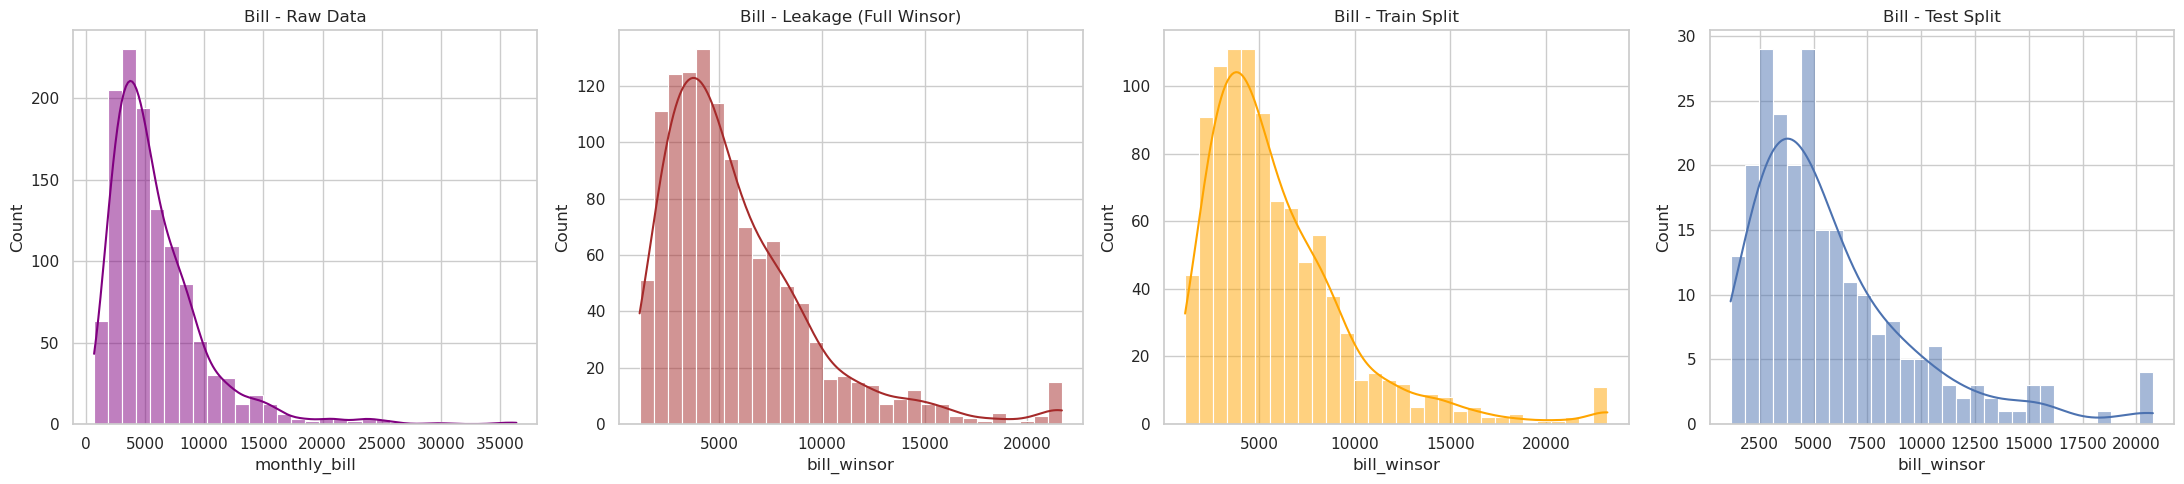

In [50]:
sns.set(style="whitegrid")

plt.figure(figsize=(22, 5))

# Raw Bill
plt.subplot(1, 4, 1)
sns.histplot(df["monthly_bill"], kde=True, bins=30,color="purple")
plt.title("Bill - Raw Data")

# Leakage (Min-Max full dataset)
plt.subplot(1, 4, 2)
sns.histplot(df["bill_winsor"], kde=True, bins=30,color="brown")
plt.title("Bill - Leakage (Full Winsor)")

# Train split
plt.subplot(1, 4, 3)
sns.histplot(train_df["bill_winsor"], kde=True, bins=30,color="orange")
plt.title("Bill - Train Split")

# Test split
plt.subplot(1, 4, 4)
sns.histplot(test_df["bill_winsor"], kde=True, bins=30)
plt.title("Bill - Test Split")

plt.tight_layout()
plt.show()

### Check: Bill_clipped & Bill_Winsor

In [51]:
train_df.loc[
    [
        train_df["monthly_bill"].idxmin(),
        train_df["monthly_bill"].idxmax(),
    ],
    ["monthly_bill", "bill_clipped", "bill_winsor"]
]

,monthly_bill,bill_clipped,bill_winsor
893,710.0,710.00,1116.0
968,36361.0,23157.26,23208.0


## Feature Engineering

### Date Feature Engineering
Date components help models detect:

* Seasonal patterns
* Monthly behavior
* Weekly trends
* Customer signup patterns

In [52]:
# Convert to Datetime
df["signup_date"] = pd.to_datetime(df["signup_date"])

In [53]:
# Extract Date Components
df["signup_year"] = df["signup_date"].dt.year
df["signup_month"] = df["signup_date"].dt.month
df["signup_dow"] = df["signup_date"].dt.dayofweek

In [54]:
df[
    [
        "signup_date",
        "signup_year",
        "signup_month",
        "signup_dow"
    ]
].head()

,signup_date,signup_year,signup_month,signup_dow
0,2019-01-01,2019,1,1
1,2019-01-02,2019,1,2
2,2019-01-03,2019,1,3
3,2019-01-04,2019,1,4
4,2019-01-05,2019,1,5


### Ratio Feature Engineering
Ratios often capture:

* Spending behavior
* Financial stress
* Customer affordability

These features are often more informative than raw values.

In [55]:
# Bill-to-Income Ratio
df["bill_to_income_ratio"] = (
    df["monthly_bill"] / df["monthly_income"]
)

In [56]:
df[
    [
        "monthly_bill",
        "monthly_income",
        "bill_to_income_ratio"
    ]
].head()

,monthly_bill,monthly_income,bill_to_income_ratio
0,10049.0,57643.0,0.174332
1,2752.0,18207.0,0.151151
2,3155.0,13075.0,0.241300
3,5859.0,38890.0,0.150656
4,5106.0,17475.0,0.292189


### Text Feature Engineering
Longer feedback may indicate:

* Frustration
* Detailed complaints
* Higher engagement

In [57]:
df["feedback_length"] = (
    df["customer_feedback"].str.len()
)

In [58]:
df[
    [
        "customer_feedback",
        "feedback_length"
    ]
].head()

,customer_feedback,feedback_length
0,Coverage is poor in my location,31
1,Billing issues occurred multiple times,38
2,Billing issues occurred multiple times,38
3,Customer support was helpful,28
4,Coverage is poor in my location,31


In [59]:
df.loc[[df["feedback_length"].idxmin(),df["feedback_length"].idxmax()],["customer_feedback",
        "feedback_length"]]

,customer_feedback,feedback_length
12,Happy with data packages,24
14,Service is unreliable during peak hours,39


#### Complaint Detection Using Keywords

If feedback contains words like: slow, poor, expensive, unreliable, drops

Then:
`complaint_flag = 1`
Otherwise:
`complaint_flag = 0`

This converts text into machine-learning-friendly numerical data.

In [60]:
df["complaint_flag"] = (
    df["customer_feedback"]
    .str.contains(
        "slow|poor|expensive|unreliable|drops",
        case=False,
        na=False
    )
    .astype(int)
)

In [61]:
df[
    [
        "customer_feedback",
        "complaint_flag"
    ]
].head()

,customer_feedback,complaint_flag
0,Coverage is poor in my location,1
1,Billing issues occurred multiple times,0
2,Billing issues occurred multiple times,0
3,Customer support was helpful,0
4,Coverage is poor in my location,1


In [62]:
counts = df["complaint_flag"].value_counts()

print("No Complaint (0):", counts.get(0, 0))
print("Complaint (1):", counts.get(1, 0))

No Complaint (0): 598
Complaint (1): 602


### Interaction Features
Interaction features help models learn relationships between variables.

Example:

* High bill + many complaints
* May indicate higher churn probability

In [63]:
# Create Interaction Feature

df["support_bill_interaction"] = (
    df["support_tickets"] * df["monthly_bill"]
)

In [64]:
df[
    [
        "support_tickets",
        "monthly_bill",
        "support_bill_interaction"
    ]
].head()

,support_tickets,monthly_bill,support_bill_interaction
0,1,10049.0,10049.0
1,2,2752.0,5504.0
2,0,3155.0,0.0
3,2,5859.0,11718.0
4,0,5106.0,0.0


### Final Engineered Features

In [65]:
df[
    [
        "signup_month",
        "bill_to_income_ratio",
        "support_bill_interaction",
        "feedback_length",
        "complaint_flag"
    ]
].head()

,signup_month,bill_to_income_ratio,support_bill_interaction,feedback_length,complaint_flag
0,1,0.174332,10049.0,31,1
1,1,0.151151,5504.0,38,0
2,1,0.241300,0.0,38,0
3,1,0.150656,11718.0,28,0
4,1,0.292189,0.0,31,1


## Separate Features and Target
### Features X are the columns used to predict the target
`drop("churn", axis=1)`
- remove churn column
- keep all other columns
### Target Y is the column you want the model to predict.
`churn`
- 1 → customer left
- 0 → customer stayed

In [66]:
# Training Data 
X_train = train_df.drop("churn", axis=1) 
Y_train = train_df["churn"] 

In [67]:
# Testing Data 
X_test = test_df.drop("churn", axis=1) 
Y_test = test_df["churn"] 

In [68]:
# Check Dataset Shapes 
X_train.shape, X_test.shape

((960, 18), (240, 18))